# Partie II — CNN et Vision par Ordinateur
## Projet Deep Learning EMSI 2025–2026

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


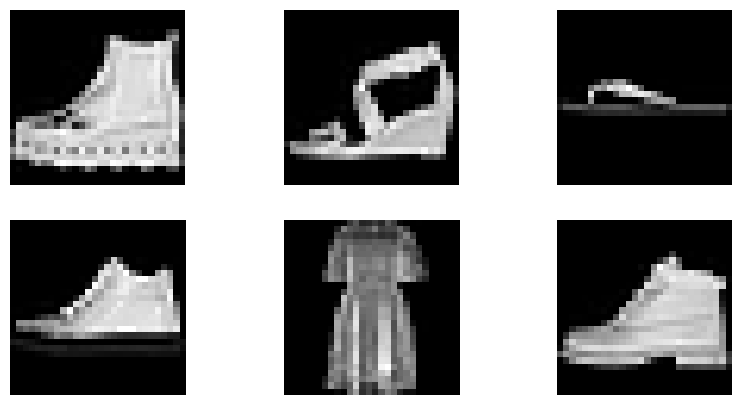

In [6]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.axis('off')

plt.show()


In [7]:
def corr2d(X, K):

    h, w = K.shape

    Y = torch.zeros((X.shape[0]-h+1,
                     X.shape[1]-w+1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):

            Y[i,j] = (X[i:i+h, j:j+w] * K).sum()

    return Y


In [8]:
def max_pool2d(X, size=2):

    h, w = X.shape

    output = torch.zeros((h//size, w//size))

    for i in range(0, h, size):
        for j in range(0, w, size):

            output[i//size, j//size] = X[i:i+size, j:j+size].max()

    return output


In [9]:
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1,32,3,padding=1)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64*7*7,128)

        self.fc2 = nn.Linear(128,10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x


In [10]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [11]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(epoch+1, epoch_loss, epoch_accuracy)


1 0.4713101625791999 0.82925
2 0.29685984991951536 0.8923833333333333
3 0.25003941472309993 0.9079666666666667
4 0.2236414735537094 0.9179833333333334
5 0.19566656656261447 0.9276833333333333


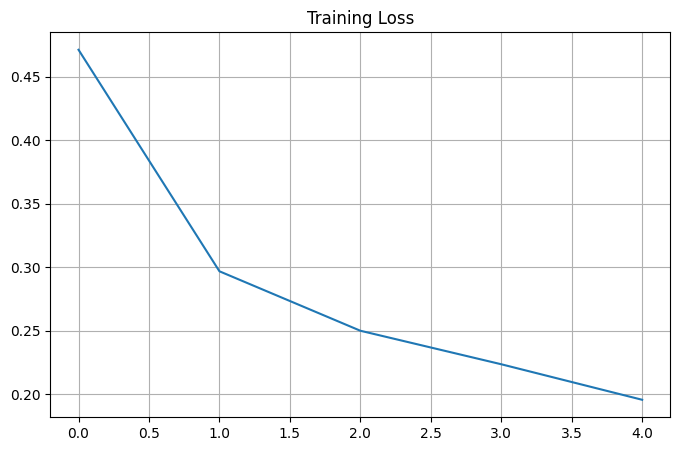

In [12]:
plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("Training Loss")
plt.grid()
plt.show()


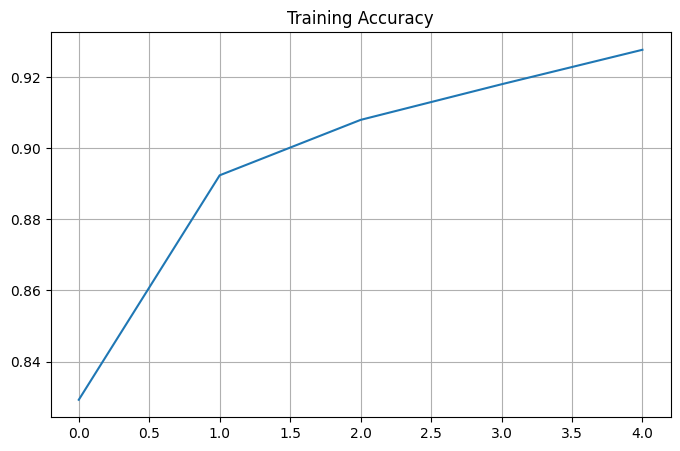

In [13]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.grid()
plt.show()


In [14]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.numpy())


In [15]:
accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy :", accuracy)

print(classification_report(all_labels, all_preds))


Accuracy : 0.9157
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1000
           1       0.99      0.98      0.99      1000
           2       0.87      0.87      0.87      1000
           3       0.90      0.94      0.92      1000
           4       0.86      0.86      0.86      1000
           5       0.99      0.98      0.98      1000
           6       0.81      0.68      0.74      1000
           7       0.96      0.97      0.97      1000
           8       0.99      0.98      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.91     10000
weighted avg       0.92      0.92      0.91     10000



[[915   0  12  16   1   1  50   0   5   0]
 [  0 983   0  13   1   0   2   0   1   0]
 [ 19   1 874   9  49   0  48   0   0   0]
 [ 19   3   8 942   9   0  19   0   0   0]
 [  1   0  63  39 859   0  38   0   0   0]
 [  0   0   0   0   0 978   0  13   0   9]
 [148   1  51  30  81   0 682   0   7   0]
 [  0   0   0   0   0   7   0 967   0  26]
 [  4   2   1   2   1   1   3   2 984   0]
 [  1   0   0   0   0   4   0  22   0 973]]


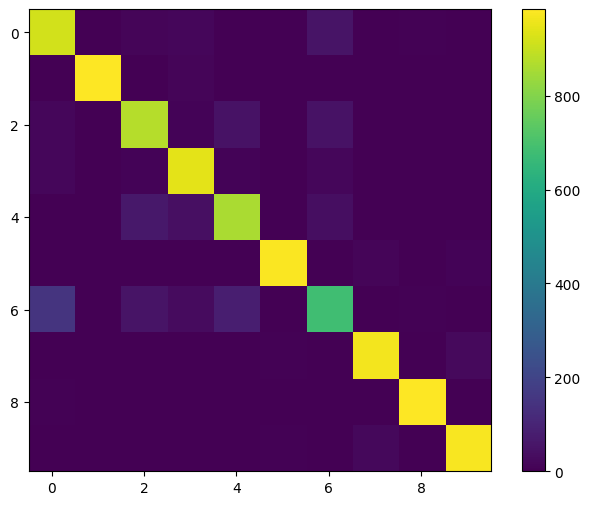

In [16]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()
plt.show()


In [17]:
torch.save(model.state_dict(), "cnn_model.pth")

print("Model saved")


Model saved


# Conclusion

Cette partie montre l’efficacité des CNN pour les tâches de vision par ordinateur et la classification d’images.
